# Анализ лояльности пользователей Яндекс Афиши

##Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [160]:
#Загрузка модулей
!pip install psycopg2 -q

#Импортируем библиотеки
import pandas as pd
from sqlalchemy import create_engine
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import phik
import warnings

In [91]:
#Создание конфигурации 
db_config = {'user': 'praktikum_student', # имя пользователя
             'pwd': 'Sdf4$2;d-d30pp', # пароль
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432, # порт подключения
             'db': 'data-analyst-afisha' # название базы данных
             }

#Формирование строки для соединения
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

#Создание соединения
engine = create_engine(connection_string)

In [92]:
#SQL запрос
query = '''
WITH top_device AS  (
	SELECT p.device_type_canonical 
	FROM afisha.purchases p 
	GROUP BY p.device_type_canonical
	ORDER BY count(*) DESC 
	LIMIT 2
)

SELECT 	
		user_id,
		device_type_canonical,
		order_id,
		created_dt_msk AS order_dt,
		created_ts_msk as order_ts,
    currency_code,
		revenue,
		tickets_count,
		created_dt_msk::date - LAG(created_dt_msk::date)
		OVER (PARTITION BY user_id ORDER BY created_dt_msk) AS days_since_prev,
    	e.event_id,
    	e.event_name_code AS event_name,
    	e.event_type_main,
    	p.service_name,
    	region_name,
    	city_name  	
FROM afisha.purchases p 
	LEFT JOIN afisha.events e ON p.event_id = e.event_id
	LEFT JOIN afisha.city c ON e.city_id =c.city_id 
	LEFT JOIN afisha.regions r ON r.region_id =c.region_id 
WHERE device_type_canonical IN (SELECT device_type_canonical FROM top_device) and e.event_type_main != 'фильм'
ORDER BY user_id 
'''

#Запись результата SQL-запроса
df = pd.read_sql_query(query, con=engine)

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [93]:
print(f'В датасете {df.shape[0]} строк и {df.shape[1]} столбцов')

В датасете 290611 строк и 15 столбцов


In [94]:
df.head(5)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

Объем занимаемой памяти составляет 33,3 МВ 

По результатам анализа типизации столбцов можно оптимизировать несколько признаков. Столбцы `device_type_canonical`, `currency_code`, `event_type_main`, `service_name`, `region_name` и `city_name` содержат ограниченный набор повторяющихся текстовых значений, поэтому их целесообразно преобразовать из типа `object` в `category`. Это позволит сократить потребление памяти и ускорить выполнение некоторых операций. Столбец `tickets_count` имеет тип `int64`, однако его значения находятся в небольшом диапазоне, поэтому его можно привести к менее ёмкому целочисленному типу (например, `int8` или `int16`) для дополнительной экономии памяти. Остальные столбцы имеют подходящие типы данных и не требуют изменения.

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [96]:
kzt_rub_exchange_rate = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')
kzt_rub_exchange_rate.head(5)

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [97]:
kzt_rub_exchange_rate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [98]:
#Изменяем типизацию 
kzt_rub_exchange_rate['data'] =pd.to_datetime(kzt_rub_exchange_rate['data'])


curs = kzt_rub_exchange_rate.set_index('data')['curs']
df['revenue_rub'] = np.where(
    df['currency_code'] == 'rub',
    df['revenue'],
    df['revenue'] * df['order_dt'].map(curs) / 100
)

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [99]:
print('Количество пропусков по столбцам:')
df.isna().sum()

Количество пропусков по столбцам:


user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
region_name                  0
city_name                    0
revenue_rub                  0
dtype: int64

In [100]:
#Преобразуем типы данных
df['device_type_canonical'] = df['device_type_canonical'].astype('category')
df['currency_code'] = df['currency_code'].astype('category')
df['event_type_main'] = df['event_type_main'].astype('category')
df['service_name'] = df['service_name'].astype('category')
df['region_name'] = df['region_name'].astype('category')
df['city_name'] = df['city_name'].astype('category')
df['tickets_count'] = pd.to_numeric(df['tickets_count'], downcast='integer')
df['order_id'] = pd.to_numeric(df['order_id'], downcast = 'integer')


In [101]:
df['device_type_canonical'].unique()

['mobile', 'desktop']
Categories (2, object): ['desktop', 'mobile']

In [102]:
df['currency_code'].unique()


['rub', 'kzt']
Categories (2, object): ['kzt', 'rub']

In [103]:
df['event_type_main'].unique()

['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт', 'ёлки']
Categories (7, object): ['выставки', 'другое', 'концерты', 'спорт', 'стендап', 'театр', 'ёлки']

In [104]:
df['service_name'].unique()

['Край билетов', 'Мой билет', 'За билетом!', 'Лови билет!', 'Билеты без проблем', ..., 'Цвет и билет', 'Зе Бест!', 'Тех билет', 'Лимоны', 'Билеты в интернете']
Length: 36
Categories (36, object): ['Crazy ticket!', 'Show_ticket', 'Билет по телефону', 'Билеты без проблем', ..., 'Тех билет', 'Цвет и билет', 'Шоу начинается!', 'Яблоко']

In [105]:
df['region_name'].unique()

['Каменевский регион', 'Североярская область', 'Озернинский край', 'Лугоградская область', 'Поленовский край', ..., 'Сосноводолинская область', 'Верхозёрский край', 'Лесноярский край', 'Теплоозёрский округ', 'Лесополянская область']
Length: 81
Categories (81, object): ['Белоярская область', 'Берестовский округ', 'Берёзовская область', 'Боровлянский край', ..., 'Широковская область', 'Яблоневская область', 'Ягодиновская область', 'Яснопольский округ']

In [106]:
df['revenue_rub'].describe()

count    290611.000000
mean        555.571987
std         875.498172
min         -90.760000
25%         113.970000
50%         351.140000
75%         802.050000
max       81174.540000
Name: revenue_rub, dtype: float64

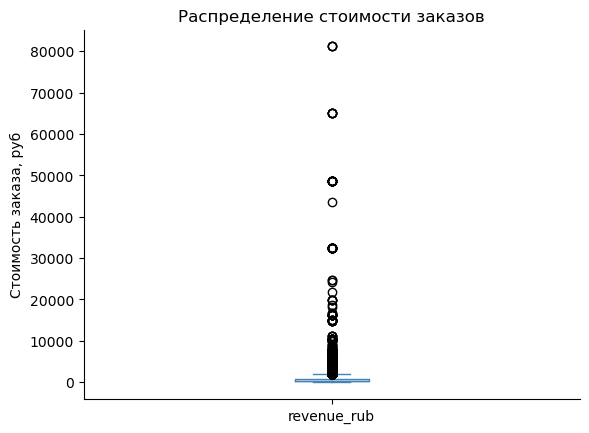

In [107]:
ax = df['revenue_rub'].plot(
                        kind='box',
                        title ='Распределение стоимости заказов',
                        ylabel = 'Стоимость заказа, руб',
                        color='steelblue'
            )

ax.spines[['top', 'right']].set_visible(False)

In [108]:
print(df['revenue_rub'].quantile([0.9, 0.99, 0.999]))

0.900    1294.770000
0.990    2628.421739
0.999    5140.780000
Name: revenue_rub, dtype: float64


In [109]:
df = df[df['revenue_rub'] <= df['revenue_rub'].quantile(0.99)]
df = df[df['revenue_rub']>= 0]

Статистический анализ столбца `revenue_rub` показал наличие аномальных значений. В данных присутствуют отрицательные суммы выручки, которые не соответствуют логике исследуемых продаж и могут быть связаны с возвратами, отменами заказов или ошибками в данных. Поскольку целью анализа является изучение выручки от совершенных покупок, отрицательные значения были исключены.

Кроме того, распределение выручки имеет длинный правый хвост: небольшое количество заказов с очень высокой стоимостью существенно отличается от основной массы наблюдений. Для снижения влияния выбросов на результаты анализа были исключены значения выше 99-го процентиля. Это позволяет получить более репрезентативную картину поведения большинства пользователей и избежать искажения средних показателей экстремальными значениями.

In [110]:
df['tickets_count'].describe()   

count    287405.000000
mean          2.741323
std           1.163087
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          57.000000
Name: tickets_count, dtype: float64

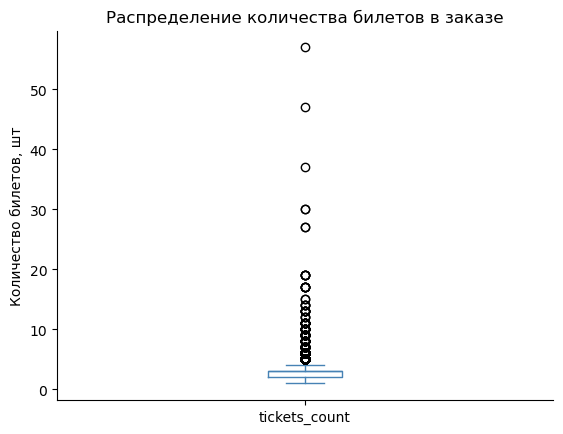

In [111]:
ax2 = df['tickets_count'].plot(
                                kind='box',
                                title = 'Распределение количества билетов в заказе',
                                ylabel = 'Количество билетов, шт',
                                color='steelblue')

ax2.spines[['top', 'right']].set_visible(False)

Стаистический анализ столбца `tickets_count` показал, что большинство заказов содержат от 2 до 3 билетов. Минимальное значение равно 1, что соответствует логике данных. Несмотря на наличие заказов с большим количеством билетов (до 57), на данном этапе они не исключались, поскольку могут отражать реальные групповые или корпоративные покупки, а не ошибки в данных.

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 287405 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                287405 non-null  object        
 1   device_type_canonical  287405 non-null  category      
 2   order_id               287405 non-null  int32         
 3   order_dt               287405 non-null  datetime64[ns]
 4   order_ts               287405 non-null  datetime64[ns]
 5   currency_code          287405 non-null  category      
 6   revenue                287405 non-null  float64       
 7   tickets_count          287405 non-null  int8          
 8   days_since_prev        265711 non-null  float64       
 9   event_id               287405 non-null  int64         
 10  event_name             287405 non-null  object        
 11  event_type_main        287405 non-null  category      
 12  service_name           287405 non-null  category 

### Итоги предобработки данных

В ходе предобработки данных были выполнены проверка пропусков, анализ типов данных и поиск аномальных значений.

В столбце **`days_since_prev`** было выявлено около 22 тысяч пропусков. Анализ показал, что они имеют смысловую природу: данный признак отражает количество дней между текущей и предыдущей покупкой, поэтому отсутствие значения означает, что для пользователя текущая покупка является первой. Следовательно, такие пропуски не являются ошибкой и не требуют удаления или заполнения.

Далее был проведен анализ типов данных. Для номинальных признаков были выбраны более подходящие типы данных, что позволило оптимизировать использование памяти. Также была выполнена проверка категориальных столбцов на наличие дублирующихся значений и различных вариантов написания категорий.

Статистический анализ столбца **`revenue_rub`** выявил наличие отрицательных значений и значительных выбросов. Отрицательные значения были исключены из датасета, поскольку не отражают выручку от завершённых продаж и, вероятнее всего, соответствуют возвратам, отменам заказов или ошибкам учета. Кроме того, были исключены значения выше 99-го процентиля. Это позволило снизить влияние экстремально крупных заказов, которые существенно искажали распределение и могли повлиять на результаты дальнейшего анализа.

Также был выполнен анализ столбца **`tickets_count`**. Несмотря на наличие отдельных заказов с большим количеством билетов, они не были исключены из датасета. Такие значения являются редкими, но реалистичными и могут соответствовать групповым или корпоративным покупкам. Оснований считать их ошибками в данных выявлено не было, поэтому они были сохранены для дальнейшего анализа.

В результате выполненной предобработки удалось существенно оптимизировать датасет. За счет изменения типов данных, использования категориальных типов для номинальных признаков и удаления аномальных наблюдений объем памяти, занимаемый данными, сократился с **33 МБ до 22 МБ**, то есть более чем на **10 МБ** (примерно на **33%**). Это позволило сделать работу с датасетом более эффективной, снизить потребление памяти и повысить производительность последующего анализа.


---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [113]:
df.sort_values(by = 'order_dt')

user_profiles  = df.groupby('user_id', as_index = False).agg(
                            first_order_dt =('order_dt','min'),
                            last_order_dt =('order_dt','max'), 
                            first_device_type =('device_type_canonical', 'first'),
                            first_region = ('region_name','first'),
                            first_service = ('service_name', 'first'),
                            first_event_type = ('event_type_main', 'first'),
                            orders_count = ('order_id', 'count'),
                            avg_revenue_rub = ('revenue_rub','mean'),
                            avg_tickets_count = ('tickets_count', 'mean'),
                            avg_days_between_orders = ('days_since_prev', 'mean'))

user_profiles['is_two'] = user_profiles['orders_count']>=2
user_profiles['is_five'] = user_profiles['orders_count']>=5                      



In [114]:
user_profiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21838 entries, 0 to 21837
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   user_id                  21838 non-null  object        
 1   first_order_dt           21838 non-null  datetime64[ns]
 2   last_order_dt            21838 non-null  datetime64[ns]
 3   first_device_type        21838 non-null  category      
 4   first_region             21838 non-null  category      
 5   first_service            21838 non-null  category      
 6   first_event_type         21838 non-null  category      
 7   orders_count             21838 non-null  int64         
 8   avg_revenue_rub          21838 non-null  float64       
 9   avg_tickets_count        21838 non-null  float64       
 10  avg_days_between_orders  13511 non-null  float64       
 11  is_two                   21838 non-null  bool          
 12  is_five                  21838 n

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [115]:
print(f'''
В выборке {user_profiles.shape[0]} пользователей
Средняя выручка с одного заказа: {user_profiles['avg_revenue_rub'].mean():.2f}
Доля пользователей с 2+ заказами: {user_profiles['is_two'].mean():.2%}
Доля пользователей с 5+ заказами: {user_profiles['is_five'].mean():.2%}
''')

print(f'''
Общее число заказов составляет {user_profiles['orders_count'].sum()}
Среднее число билетов в заказе {user_profiles['avg_tickets_count'].mean():.2f}
Среднее количество дней между покупками {user_profiles['avg_days_between_orders'].mean():.2f}
''')


В выборке 21838 пользователей
Средняя выручка с одного заказа: 545.03
Доля пользователей с 2+ заказами: 61.70%
Доля пользователей с 5+ заказами: 29.00%


Общее число заказов составляет 287405
Среднее число билетов в заказе 2.74
Среднее количество дней между покупками 15.85



**Анализ количества заказов пользователя**

In [116]:
print(f'Сатистический анализ количества заказов пользователя: \n{user_profiles['orders_count'].describe()}')

Сатистический анализ количества заказов пользователя: 
count    21838.000000
mean        13.160775
std        121.577370
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max      10168.000000
Name: orders_count, dtype: float64


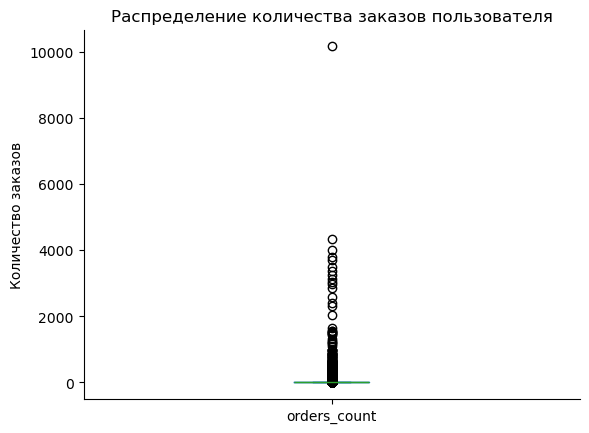

In [117]:
ax3 = user_profiles['orders_count'].plot(
                                        kind = 'box',
                                        title = 'Распределение количества заказов пользователя',
                                        ylabel = 'Количество заказов')

ax3.spines[['top', 'right']].set_visible(False)

In [118]:
print(f'Процентили количества заказов\n{user_profiles['orders_count'].quantile([0.9, 0.95, 0.99, 0.999, 0.9999, 0.99999, 1])}')

Процентили количества заказов
0.90000       15.00000
0.95000       31.00000
0.99000      152.00000
0.99900     1462.07500
0.99990     3972.11640
0.99999     8896.64986
1.00000    10168.00000
Name: orders_count, dtype: float64


In [119]:
user_profiles = user_profiles[user_profiles['orders_count']<user_profiles['orders_count'].quantile(1)]

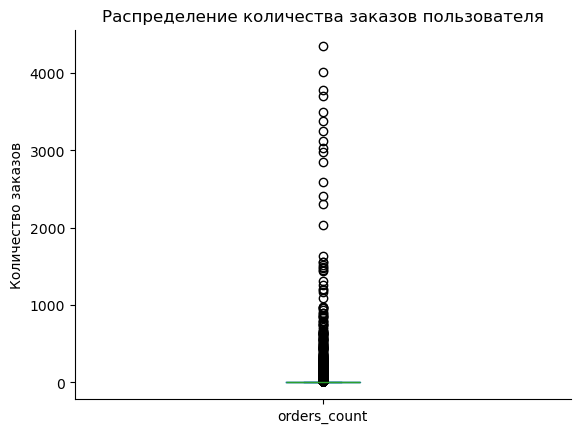

In [120]:
ax4 = user_profiles['orders_count'].plot(
                                        kind = 'box',
                                        title = 'Распределение количества заказов пользователя',
                                        ylabel = 'Количество заказов')

ax4.spines[['top', 'right']].set_visible(False)


В столбце `orders_count` присутствует одно экстремально большое значение количества заказов (100-й процентиль), которое существенно растягивает масштаб boxplot и затрудняет анализ основной части распределения. Для повышения информативности визуализации это единственное наблюдение было исключено. Поскольку удаляется только одна запись, такое решение не оказывает заметного влияния на результаты анализа.

**Анализ среднего количества билетов в заказе**

In [121]:
print(f'Статистический анализ среднего количества билетов в заказе\n{user_profiles['avg_tickets_count'].describe()}')

Статистический анализ среднего количества билетов в заказе
count    21837.000000
mean         2.744057
std          0.913103
min          1.000000
25%          2.000000
50%          2.750000
75%          3.080000
max         11.000000
Name: avg_tickets_count, dtype: float64


Медиана практически совпадает с средним, что говорит о **симметричном распределении**. Максимальное значение равно 11, что не выглядит аномальным и не требует дополнительной фильтрации

**Анализ среднего количества дней между заказами пользователя**

In [122]:
print(f'Статистический анализ количества дней между заказами пользователя\n{user_profiles['avg_days_between_orders'].describe()}')

Статистический анализ количества дней между заказами пользователя
count    13510.000000
mean        15.848239
std         22.304925
min          0.000000
25%          1.000000
50%          8.000000
75%         20.421429
max        148.000000
Name: avg_days_between_orders, dtype: float64


Средний интервал между заказами составляет 15,8 дня, при этом медиана равна 8 дням, что указывает на наличие правосторонней асимметрии распределения. У 50% пользователей средний интервал между заказами не превышает 8 дней, а у 75% — около 20 дней. Максимальное значение составляет 148 дней и не выглядит аномальным.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [123]:
first_events_group = user_profiles.groupby('first_event_type', observed=False, as_index =False).agg(
                                                                    users_count = ('user_id', 'count'),
                                                                    user_share = ('user_id', lambda user_id: user_id.count()/len(user_profiles)),
                                                                    two_orders_share = ('is_two', 'mean'))
first_device_group = user_profiles.groupby('first_device_type', observed=False, as_index =False).agg(
                                                                    users_count = ('user_id', 'count'),
                                                                    user_share = ('user_id', lambda user_id: user_id.count()/len(user_profiles)),
                                                                    two_orders_share = ('is_two', 'mean')).sort_values('user_share')
first_region_group = user_profiles.groupby('first_region', observed=False, as_index = False).agg(
                                                                    users_count = ('user_id', 'count'),
                                                                    user_share = ('user_id', lambda user_id: user_id.count()/len(user_profiles)),
                                                                    two_orders_share = ('is_two', 'mean')).sort_values('user_share')
first_service_group = user_profiles.groupby('first_service', observed=False, as_index=False).agg(
                                                                    users_count = ('user_id', 'count'),
                                                                    user_share = ('user_id', lambda user_id: user_id.count()/len(user_profiles)),
                                                                    two_orders_share = ('is_two', 'mean')).sort_values('user_share')


In [124]:
first_events_group['users_count'].describe()

count       7.000000
mean     3119.571429
std      3543.686633
min        95.000000
25%       612.500000
50%      1116.000000
75%      4874.500000
max      9652.000000
Name: users_count, dtype: float64

Распределение пользователей по сегментам (по типу первого мероприятия) является абсолютно неравномерным, так как среднее количество пользователей на сегмент составляет 3119, в то время как стандартное отклонение 2543. Тот факт, что стандартное отклонение превышает среднее значение указывает на **высокий разброс данных** и **сильную правостороннюю асиммметрию**.

In [125]:
first_device_group['users_count'].describe()

count        2.000000
mean     10918.500000
std      10102.434583
min       3775.000000
25%       7346.750000
50%      10918.500000
75%      14490.250000
max      18062.000000
Name: users_count, dtype: float64

Поскольку в данной сегментации всего две альтернативы можно анализировать фактическое количество пользователей по сегментам: 3775 и 18062, что говорит о **неравномерном распеределении** и **явном лидере**, который берет на себя около 81% пользователей.

In [126]:
first_region_group['users_count'].describe()

count      81.000000
mean      269.592593
std       897.825300
min         1.000000
25%        22.000000
50%        55.000000
75%       217.000000
max      7166.000000
Name: users_count, dtype: float64

Распределение пользователей по регионам так же неравномерно. У 75% регионов количество пользователей меньше 217. При этом среднее значение составляет 269, а максимальное составляет 7166, Это яркий маркер географического неравенства: подавляющее большинство регионов генерирует минимальный трафик, в то время как 1-2 крупнейших регионов дают коллосальный рост вброс данных и стягивают на себя всю статистику.

In [127]:
first_service_group['users_count'].describe()

count      36.000000
mean      606.583333
std      1153.770276
min         0.000000
25%        18.250000
50%        91.500000
75%       383.750000
max      5199.000000
Name: users_count, dtype: float64

Распределение по типу сервиса так же **неравномерно**, так как 75% операторов имеют меньше 383 пользователей, в то время как лидирующий сегмент имеет 5199 пользователей, стандартное отклонение, которое в два раза больше среднего это подтверждает.

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


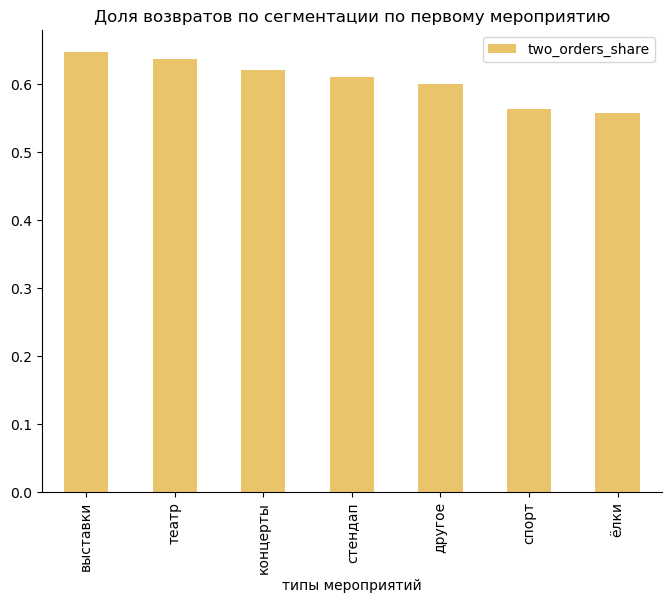

In [128]:
ax5 = first_events_group.sort_values(by= 'two_orders_share', ascending = False).plot(
                        kind = 'bar',
                        x = 'first_event_type',
                        y = 'two_orders_share',
                        title = 'Доля возвратов по сегментации по первому мероприятию',
                        xlabel = 'типы мероприятий',
                        figsize = (8,6),
                        color  = '#e9c46a'
                        )
ax5.spines[['top', 'right']].set_visible(False)


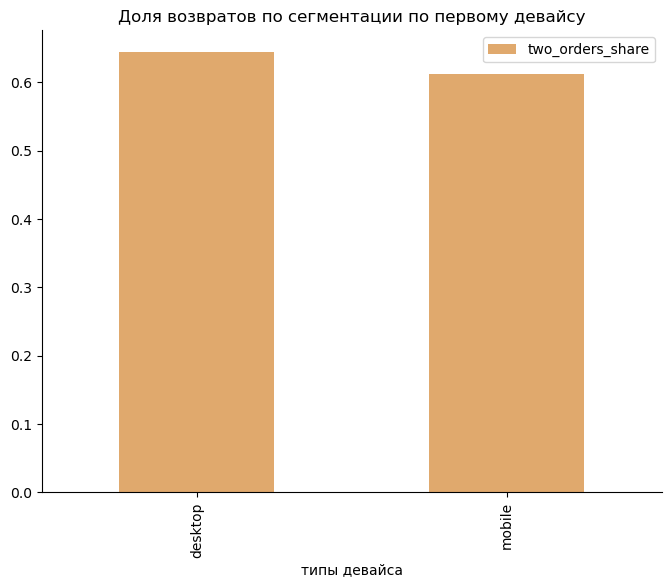

In [129]:
ax6 = first_device_group.sort_values(by= 'two_orders_share', ascending = False).plot(
                        kind = 'bar',
                        x = 'first_device_type',
                        y = 'two_orders_share',
                        title = 'Доля возвратов по сегментации по первому девайсу',
                        xlabel = 'типы девайса',
                        figsize = (8,6),
                        color  = '#E0A96D'
                        )
ax6.spines[['top', 'right']].set_visible(False)

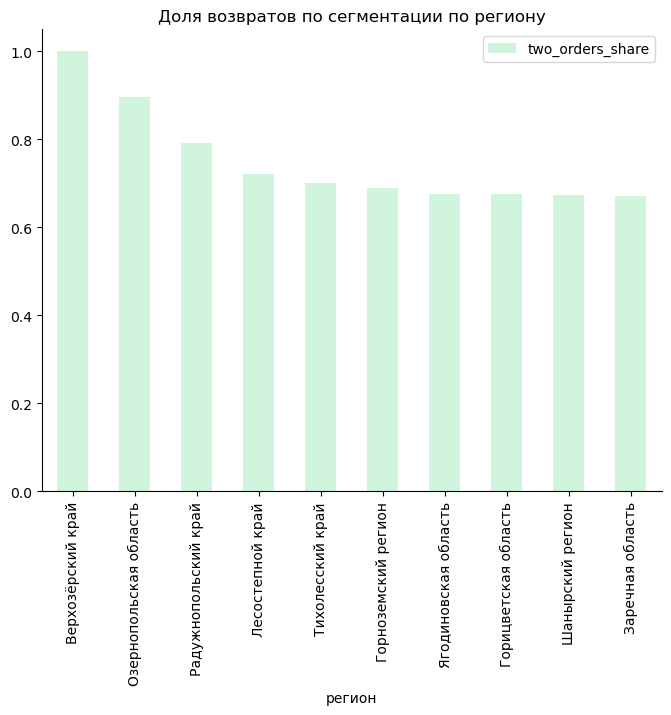

In [130]:
ax7 = first_region_group.sort_values(by= 'two_orders_share', ascending = False).head(10).plot(
                        kind = 'bar',
                        x = 'first_region',
                        y = 'two_orders_share',
                        title = 'Доля возвратов по сегментации по региону',
                        xlabel = 'регион',
                        figsize = (8,6),
                        color  = '#D0F4DE'
                        )
ax7.spines[['top', 'right']].set_visible(False)

In [131]:
first_region_group.sort_values(by= 'two_orders_share', ascending = False).describe()

,users_count,user_share,two_orders_share
count,81.000000,81.000000,81.000000
mean,269.592593,0.012346,0.560040
std,897.825300,0.041115,0.145040
min,1.000000,0.000046,0.000000
25%,22.000000,0.001007,0.500000
50%,55.000000,0.002519,0.583333
75%,217.000000,0.009937,0.636364
max,7166.000000,0.328159,1.000000


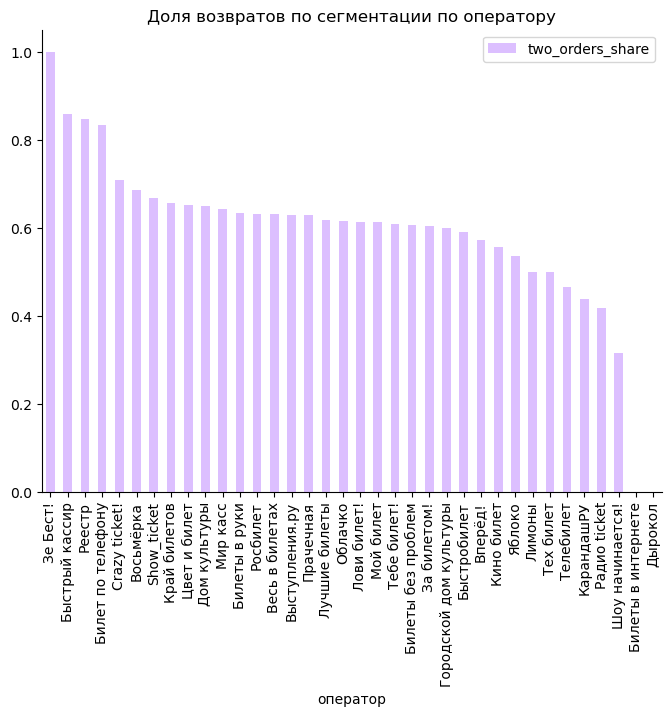

In [132]:


ax8 = first_service_group.sort_values(by= 'two_orders_share', ascending = False).plot(
                        kind = 'bar',
                        x = 'first_service',
                        y = 'two_orders_share',
                        title = 'Доля возвратов по сегментации по оператору',
                        xlabel = 'оператор',
                        figsize = (8,6),
                        color  = '#DCBFFF'
                        )
ax8.spines[['top', 'right']].set_visible(False)

In [148]:
first_service_group.sort_values(by= 'two_orders_share', ascending = False).describe()

,users_count,user_share,two_orders_share
count,36.000000,36.000000,34.000000
mean,606.583333,0.027778,0.620943
std,1153.770276,0.052836,0.129321
min,0.000000,0.000000,0.315789
25%,18.250000,0.000836,0.576087
50%,91.500000,0.004190,0.616211
75%,383.750000,0.017573,0.651387
max,5199.000000,0.238082,1.000000


**Тип первого мероприятия**
Результат: Доли повторных покупок между ключевыми категориями практически идентичны. Выставки и театры находятся на уровне ~0.60%, а спортивные события и ёлки составляют ~0.56%.Вывод: Тип первого мероприятия не оказывает влияния на удержание. Вероятность возврата стабильно низкая для любого контента.
**Первое устройство** 
Результат: Тип платформы никак не влияет на лояльность. После первой покупки клиенты на смартфонах и ноутбуках уходят одинаково часто.
**География** 
Результат: При среднем показателе возврата в 0.56%, выявлена экстремальная поляризация рынка:25% всех регионов показывают критически низкий Retention — менее 0.5%.Верхний край демонстрирует аномальный результат на уровне ~100% (1.0).Польская область и Радужный польский край удерживают планку выше 80% (>0.8).Вывод: Региональный фактор имеет критически высокую статистическую значимость. Средний показатель 0.56% обманчив. Рынок держится на нескольких сверхэффективных регионах-драйверах, пока четверть регионов практически не генерирует повторные продажи.4. 
**Операторы** 
Результат: Выявлена полярная структура распределения: Четыре оператора являются абсолютными лидерами с долей возврата более 80%: это «The Best», «Быстрый кассир», «Реестр» и «Билет по телефону».У остальных операторов идет плавное снижение доли в диапазоне от 70% до 30%.В сегменте «Билеты в интернете» зафиксирован абсолютный ноль (0% возвратов).Вывод: Канал покупки — самый сильный статистический маркер лояльности в исследовании. Разница между 80% и 0% указывает на фундаментальное различие в качестве аудитории или на технические особенности учета клиентов.
**Итоговый синтез данных и стратегические гипотезы**


---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

<Axes: xlabel='first_event_type'>

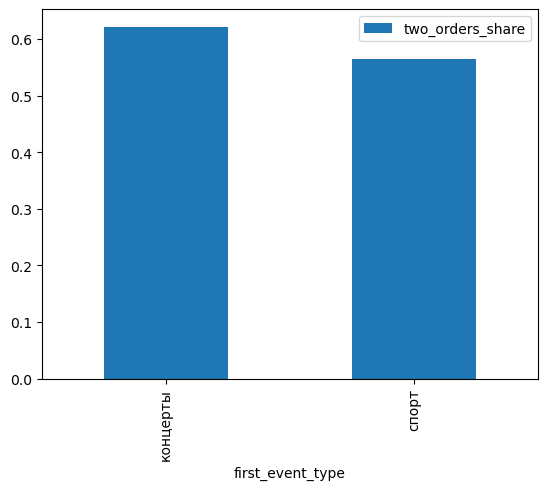

In [134]:
first_events_group[first_events_group['first_event_type'].isin(['спорт', 'концерты'])].plot(kind='bar', x ='first_event_type', y ='two_orders_share')

<Axes: xlabel='users_count', ylabel='two_orders_share'>

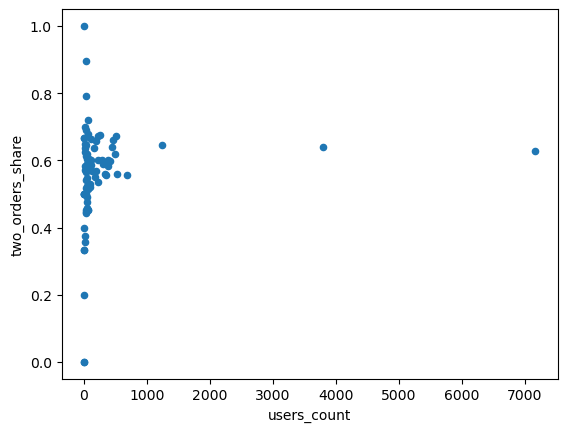

In [135]:
first_region_group.plot(kind = 'scatter', x ='users_count', y ='two_orders_share')

In [158]:
print(f'Коэффициент корреляции составляет {first_region_group['users_count'].corr(first_region_group['two_orders_share']):.2f}')

Коэффициент корреляции составляет 0.12


Концерты: доля клиентов с повторными заказами превышает 60% (~0.62).

Спорт: показатель удержания находится на уровне около 56% (~0.56).

**Гипотеза не подтвердилась.** Предложение о том, что спортивные мероприятия приводят к более частому возврату пользователей по сравнению с концертами, ошибочно.

**Гипотеза не подтвердилась.** Коэффициент корреляции показывает слабую связь между количеством пользователей и долей повторных заказов. Коэффиент положительный, а это значит при росте одной переменной растет и другая, но эта тенденция абсолютно случайна. График это подтверждает

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


<Axes: title={'center': 'Гистограммы распределения средней выручки пользователей'}, ylabel='Frequency'>

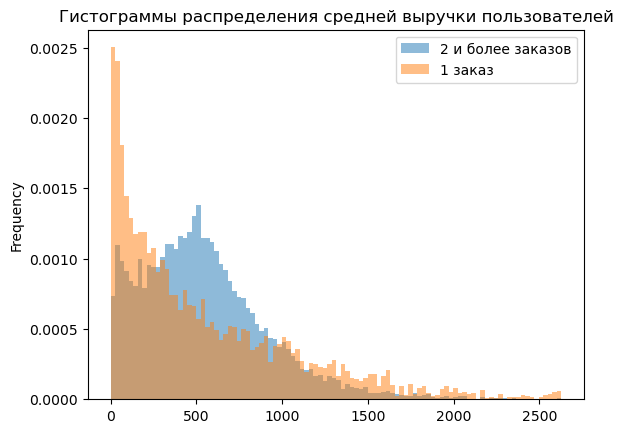

In [136]:
ax9 = user_profiles[user_profiles['is_two'] == True].plot(
                                                    kind = 'hist',
                                                    y = 'avg_revenue_rub',
                                                    alpha = 0.5,
                                                    bins = 100,
                                                    density = True,
                                                    label = '2 и более заказов', 
                                                    title = 'Гистограммы распределения средней выручки пользователей'
    
)
user_profiles[user_profiles['is_two'] == False].plot(
                                                    kind = 'hist',
                                                    y = 'avg_revenue_rub',
                                                    alpha = 0.5,
                                                    ax=ax9,
                                                    bins =100,
                                                    density = True,
                                                    label = '1 заказ'
    
)


**Диапазоны концентрации средней выручки:**

У обеих групп ключевая масса пользователей сосредоточена в диапазоне от 0 до 1 500 рублей за средний чек.

При этом у пользователей с 1 заказом распределение имеет длинный «хвост» вправо, доходящий до 2 500 рублей и выше, тогда как у пользователей с 2+ заказами значения после 2 000 рублей встречаются гораздо реже.

**Различия в форме распределений:**

Пользователи с 1 заказом: Наблюдается ярко выраженное убывающее распределение с единственным высоким пиком у самого нуля (самый дешевый сегмент билетов/заказов) и плавным спадом.

Пользователи с 2+ заказами: Распределение имеет двоякий характер (бимодальное). Помимо пика около нуля, отчетливо виден второй выраженный пик в районе 500 рублей.

**Итог:** Вернувшиеся пользователи (2+ заказа) чаще совершают покупки со средней выручкой около 500 рублей, образуя устойчивое ядро аудитории, тогда как среди одноразовых покупателей преобладают либо совсем дешевые заказы, либо единичные чеки с высоким чеком (до 2 500+ руб.).

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


<Axes: title={'center': 'Гистограммы распределения средней выручки пользователей'}, ylabel='Frequency'>

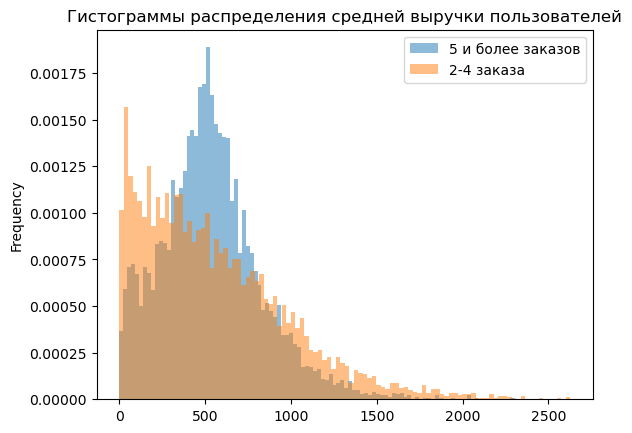

In [137]:
ax10 = user_profiles[user_profiles['is_five'] == True].plot(
                                                    kind = 'hist',
                                                    y = 'avg_revenue_rub',
                                                    alpha = 0.5,
                                                    bins = 100,
                                                    density = True,
                                                    label = '5 и более заказов', 
                                                    title = 'Гистограммы распределения средней выручки пользователей'
    
)
user_profiles[(user_profiles['is_five'] == False) & (user_profiles['is_two']==True)].plot(
                                                    kind = 'hist',
                                                    y = 'avg_revenue_rub',
                                                    alpha = 0.5,
                                                    ax=ax10,
                                                    bins =100,
                                                    density = True,
                                                    label = '2-4 заказa'
    
)


---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

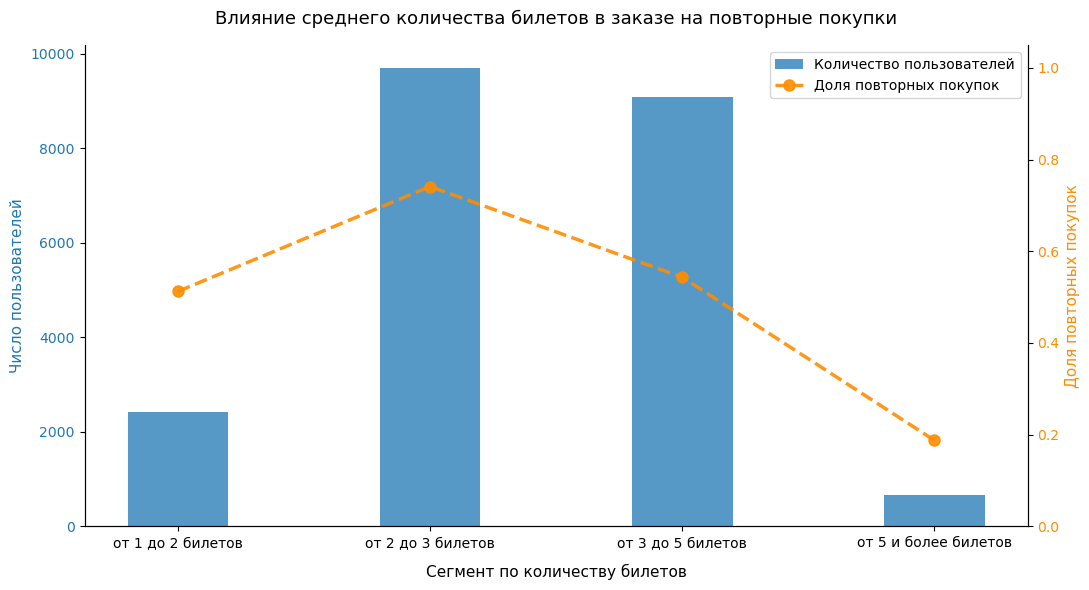

In [138]:

user_profiles['ticket_segment'] = pd.cut(
    user_profiles['avg_tickets_count'],
    [1, 2, 3, 5, np.inf],
    labels=[
        'от 1 до 2 билетов',
        'от 2 до 3 билетов',
        'от 3 до 5 билетов',
        'от 5 и более билетов',
    ],
    right=False,
)

group_ticket_segment = user_profiles.groupby(
    'ticket_segment', observed=False, as_index=False
).agg(users_count=('user_id', 'count'), two_orders_share=('is_two', 'mean'))


fig, ax1 = plt.subplots(figsize=(11, 6))

x_labels = group_ticket_segment['ticket_segment'].astype(str)
x = np.arange(len(x_labels))  # Индексы для точного совпадения осей


color_bars = 'tab:blue'
bars = ax1.bar(
    x,
    group_ticket_segment['users_count'],
    width=0.4,
    color=color_bars,
    alpha=0.75,
    label='Количество пользователей',
)

ax1.set_xlabel('Сегмент по количеству билетов', fontsize=11, labelpad=10)
ax1.set_ylabel('Число пользователей', color=color_bars, fontsize=11)
ax1.tick_params(axis='y', labelcolor=color_bars)
ax1.set_xticks(x)
ax1.set_xticklabels(x_labels, rotation=0)  


ax2 = ax1.twinx()

color_line = 'darkorange'
line = ax2.plot(
    x,
    group_ticket_segment['two_orders_share'],
    color=color_line,
    marker='o',
    markersize=8,
    linestyle='--',
    linewidth=2.5,
    alpha=0.9,
    label='Доля повторных покупок',
)

ax2.set_ylabel('Доля повторных покупок', color=color_line, fontsize=11)
ax2.tick_params(axis='y', labelcolor=color_line)
ax2.set_ylim(0, 1.05)  


handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    handles1 + handles2, labels1 + labels2, loc='upper right', frameon=True
)


ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.title(
    'Влияние среднего количества билетов в заказе на повторные покупки',
    fontsize=13,
    pad=15,
)
plt.tight_layout()
plt.show()

**Распределение пользователей по сегментам:**
Пользователи распределены **неравномерно** (сконцентрировано). Основная масса клиентов сосредоточена в двух средних сегментах: «от 2 до 3 билетов» и «от 3 до 5 билетов». Сегменты с единичными покупками (1–2 билета) и крупными заказами (от 5 билетов и более) представляют меньшую часть аудитории, причём группа «от 5 и более билетов» — наименьшая по численности.

**Анализ долей повторных покупок и аномалии:**

Аномально низкая доля: Наблюдается в сегменте «от 5 и более билетов» (всего порядка 0.2 / 20%). Это объяснимо спецификой таких заказов: разовые групповые или корпоративные покупки редко совершаются регулярно одним и тем же пользователем.
Наибольшая лояльность: Высокая доля повторных покупок (около 0.7 / 70%) характерна для пользователей, покупающих в среднем от 2 до 5 билетов.


---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [139]:
days_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday',
]
user_profiles['first_order_dayname'] =pd.Categorical(user_profiles['first_order_dt'].dt.day_name(), categories =days_order, ordered=True)

group_day_name = user_profiles.groupby('first_order_dayname', observed =False, as_index = False).agg(
                                                                                                     users_count = ('user_id', 'count'),
                                                                                                     share_two_orders = ('is_two', 'mean')
)

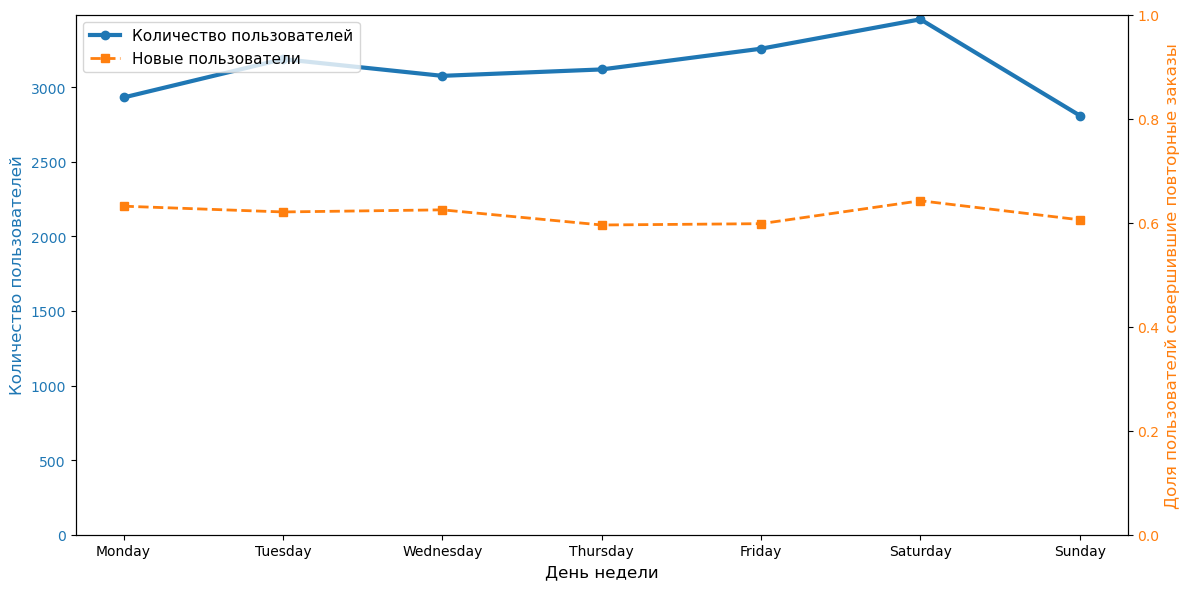

In [140]:
fig, ax1 = plt.subplots(figsize=(12, 6))


color_rev = 'tab:blue'
ax1.set_xlabel('День недели', fontsize=12)
ax1.set_ylabel('Количество пользователей', color=color_rev, fontsize=12)


line1 = ax1.plot(group_day_name['first_order_dayname'], group_day_name['users_count'], color=color_rev, marker='o', linewidth=3, label='Количество пользователей')


ax1.tick_params(axis='y', labelcolor=color_rev)

ax1.set_ylim(bottom=0)


ax2 = ax1.twinx()

color_users = 'tab:orange'
ax2.set_ylabel('Доля пользователй совершившие повторные заказы', color=color_users, fontsize=12)

line2 = ax2.plot(group_day_name['first_order_dayname'], group_day_name['share_two_orders'], color=color_users, marker='s', linestyle='--', linewidth=2, label='Новые пользователи')

ax2.tick_params(axis='y', labelcolor=color_users)
ax2.set_ylim(0, 1)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=11)

plt.title('', fontsize=14)
plt.tight_layout() 
plt.show()

**День недели, в который совершена первая покупка, абсолютно не влияет на вероятность возврата клиента.**

Если посмотреть на оранжевую пунктирную линию, которая показывает долю пользователей, совершивших повторный заказ, то в корректном масштабе от 0 до 1 она выглядит абсолютно прямой. Показатель стабильно держится на уровне 0.6 с незначительной разницей примерно в 2%.

При этом день недели немного влияет на количество пользователей, совершивших в этот день свой первый заказ — по синей линии отчетливо видно, что в субботу их было больше всего. Но если отвечать на главный вопрос и говорить именно о доле вернувшихся клиентов, то день недели на неё никак не влияет.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [141]:
user_profiles['order_segment'] = pd.cut(
                                        user_profiles['orders_count'],
                                        bins = [1, 4,  np.inf],
                                        labels = [ '2-4 заказа', '5 и более заказов'],
                                        
)

group_order_segment = user_profiles[user_profiles['order_segment'].notna()].groupby('order_segment', observed =False, as_index = False).agg(
                                                                                    avg_days_between = ('avg_days_between_orders', 'mean'),
                                                                                    share = ('is_two', 'mean')
)

Text(0, 0.5, 'Интервал между заказами (день)')

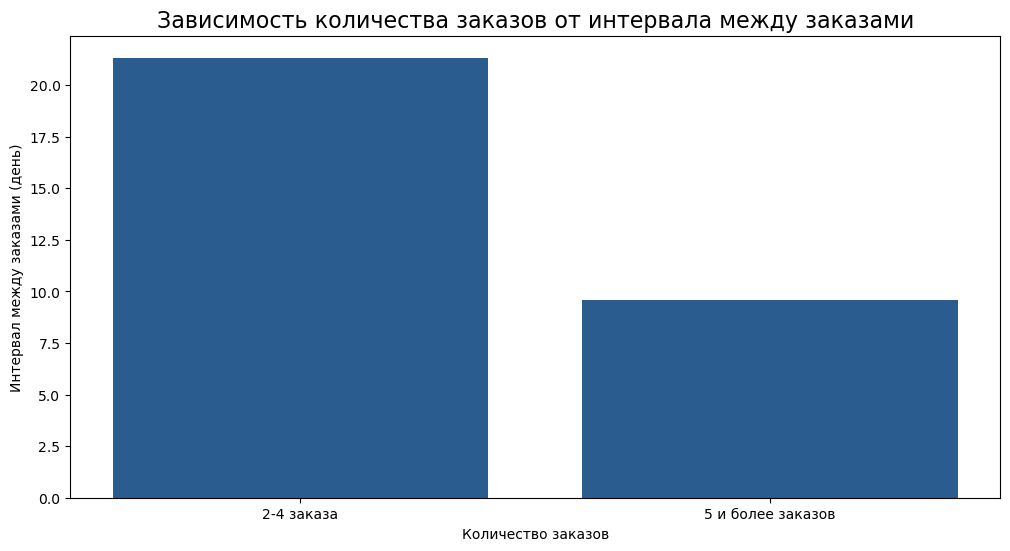

In [142]:
fig, ax1 = plt.subplots(figsize = (12, 6))

сol1 = ax1.bar(
                x = group_order_segment['order_segment'],
                height = group_order_segment['avg_days_between'],
                color = '#2b5c8f'
                )


ax1.set_title('Зависимость количества заказов от интервала между заказами', fontsize =16)
ax1.set_xlabel('Количество заказов')
ax1.set_ylabel('Интервал между заказами (день)')


Наблюдается обратная зависимость между длительностью интервала и общей лояльностью клиента: чем короче пауза между покупками, тем выше итоговая частота заказов и клиентская ценность. 

Клиенты, совершающие покупки часто (раз в 9–10 дней), уже сформировали привычку пользоваться сервисом и с гораздо большей вероятностью останутся активными..

Увеличение интервала до 3+ недель существенно повышает риск оттока, так как клиент теряет постоянный контакт с сервисом.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

Text(0.5, 1.0, 'Корреляция количества заказов с признаками профиля')

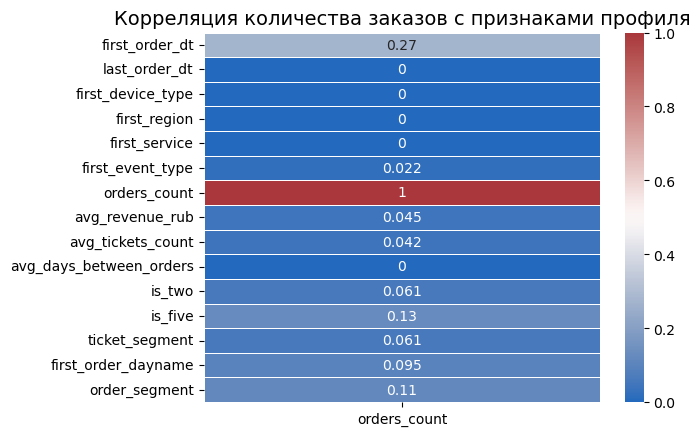

In [164]:
profiles_matrix = user_profiles.iloc[:, 1:].phik_matrix(interval_cols= ['orders_count', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between_orders'])[['orders_count']]
sns.heatmap(profiles_matrix,
            linewidths =0.5,
            cmap='vlag',
            annot= True)
plt.title('Корреляция количества заказов с признаками профиля', fontsize = 14)

<Axes: title={'center': 'Распределение количества заказов'}>

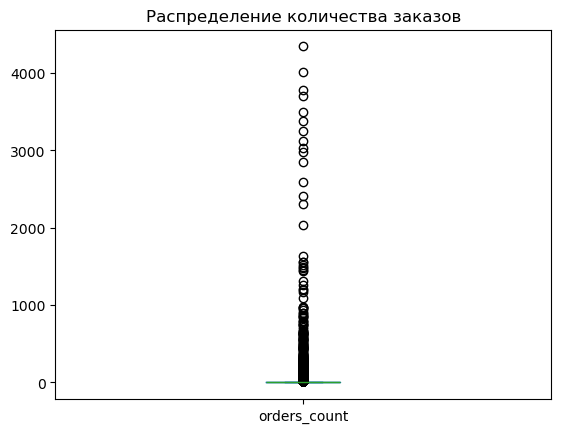

In [144]:
user_profiles['order_segment'] = user_profiles['order_segment'].cat.add_categories('1 заказ')

user_profiles['order_segment'] = user_profiles['order_segment'].fillna('1 заказ')

user_profiles['orders_count'].plot(kind = 'box',
                                  title = 'Распределение количества заказов')

<Axes: xlabel='order_segment', ylabel='orders_count'>

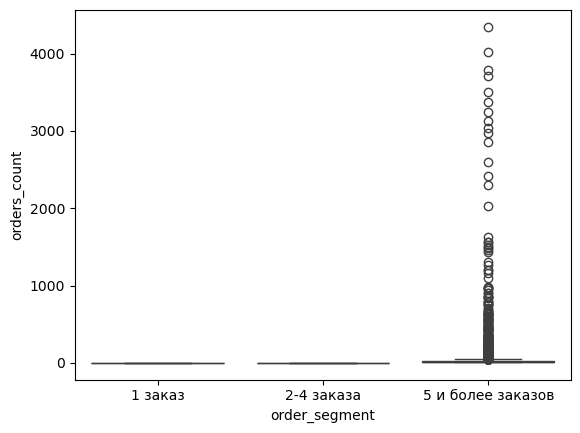

In [145]:
order = ['1 заказ', '2-4 заказа', '5 и более заказов']


sns.boxplot(
            data = user_profiles,
            x ='order_segment',
            y = 'orders_count',
            order = order)

Text(0.5, 1.0, 'Корреляция количества заказов с признаками профиля для сегмента 2-4 заказов')

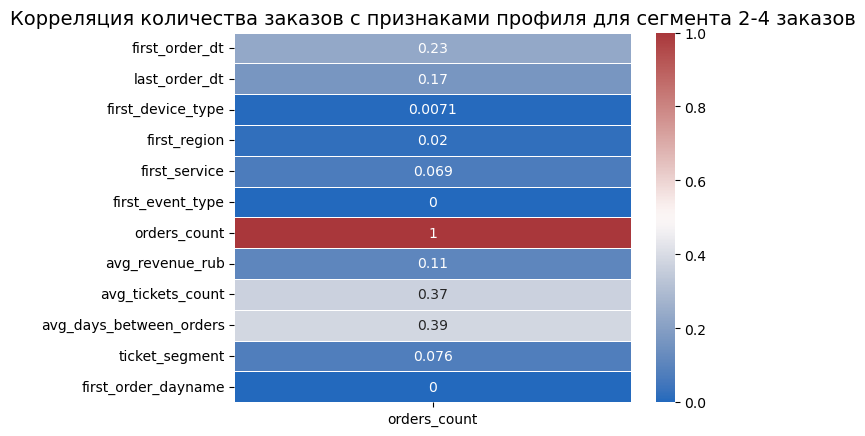

In [161]:
warnings.filterwarnings('ignore', category=UserWarning, module='phik')


profiles_matrix_2_4 = (
    user_profiles[user_profiles['order_segment'] == '2-4 заказа']
    .iloc[:, 1:]
    .phik_matrix(
        interval_cols=[
            'orders_count',
            'avg_revenue_rub',
            'avg_tickets_count',
            'avg_days_between_orders'
        ]
    )
)

sns.heatmap(
    profiles_matrix_2_4[['orders_count']],
    linewidths=0.5,
    cmap='vlag',
    annot=True
)
plt.title('Корреляция количества заказов с признаками профиля для сегмента 2-4 заказов', fontsize = 14)

Text(0.5, 1.0, 'Корреляция количества заказов с признаками профиля для сегмента 5 и более заказов')

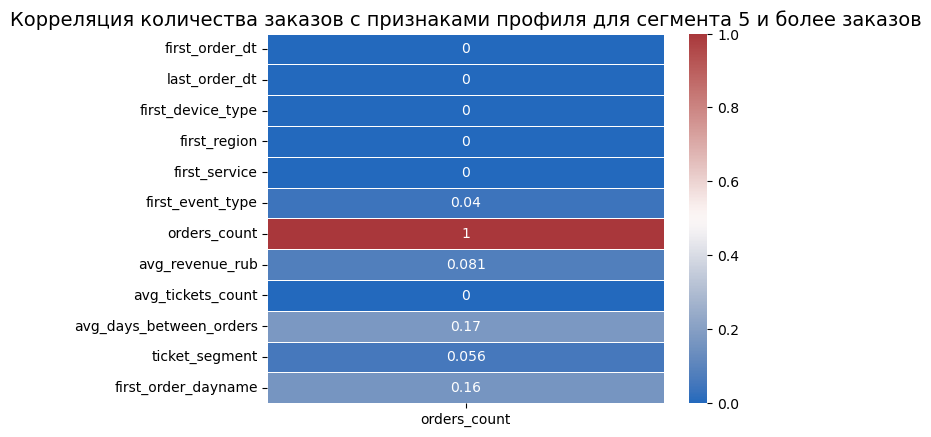

In [165]:

profiles_matrix_5_plus = (
    user_profiles[user_profiles['order_segment'] == '5 и более заказов']
    .iloc[:, 1:]
    .phik_matrix(
        interval_cols=[
            'orders_count',
            'avg_revenue_rub',
            'avg_tickets_count',
            'avg_days_between_orders'
        ]
    )
)

sns.heatmap(
    profiles_matrix_5_plus[['orders_count']],
    linewidths=0.5,
    cmap='vlag',
    annot=True
)


plt.title('Корреляция количества заказов с признаками профиля для сегмента 5 и более заказов', fontsize = 14)

**Общие данные:** На всей выборке линейные связи практически отсутствуют. Единственные слабые корреляции наблюдаются с датой первого заказа (`first_order_dt` — 0.27) и техническими флагами сегментов (`is_five` — 0.13, `order_segment` — 0.11). Остальные признаки имеют околонулевую связь с общим количеством заказов.

**Сегмент 2–4 заказов:** При сегментации проявляются прослеживаемые зависимости. В этой группе количество заказов умеренно коррелирует с:

средним перерывом между заказами (`avg_days_between_orders` — 0.39);

средним количеством билетов в заказе (`avg_tickets_count` — 0.37);

датой первого заказа (`first_order_dt` — 0.23) и датой последнего заказа (`last_order_dt` — 0.17).

**Сегмент 5 и более заказов:** Для самых активных клиентов линейная корреляция с большинством признаков снова снижается до близких к нулю значений. Слабые связи сохраняются только с интервалом между заказами (`avg_days_between_orders` — 0.17) и днем недели первого заказа (`first_order_dayname` — 0.16).

**Итог:** Линейная связь между признаками профиля и общим количеством заказов **слабо выражена**, однако в сегменте пользователей с 2–4 заказами проявляются умеренные зависимости от частоты покупок (`avg_days_between_orders`) и объёма билетов в чеке (`avg_tickets_count`).

**Анализ корреляции для сегмента клиентов с 2–4 заказами показал следующие особенности:**
Наибольшую связь с общим количеством заказов (`orders_count`) показывает средний интервал между покупками (`avg_days_between_orders` — коэффициент около 0.30). Это говорит о том, что частые повторные покупки тесно связаны с ростом их общего количества.Средняя выручка (`avg_revenue_rub`) и количество билетов (`avg_tickets_count`) имеют слабую корреляцию с числом заказов (в районе 0.05–0.10). То, сколько клиент тратит за раз или сколько билетов берет, почти не влияет на то, сделает ли он 2 заказа или 4.Категориальные признаки первого заказа (тип устройства, сервис, день недели) практически не имеют связи с итоговым количеством покупок в этом сегменте.Главный вывод: Для удержания клиентов из сегмента «2–4 заказа» ключевым фактором является регулярность (сокращение времени между заказами), а не сумма чека.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

**1. Данные и предобработка**
Проведена очистка от выбросов и аномальных значений в чеках и датах.

Суммы в тенге переведены в рубли для приведения всех финансовых показателей к единой валюте.

Сформированы пользовательские профили и сегментирована аудитория по числу покупок (1 заказ, 2–4 заказа, 5 и более заказов).

**2. Ключевые результаты анализа**
Структура базы и удержание: Подавляющее большинство пользователей совершает только 1 покупку. Средний показатель повторных продаж (Retention) находится на низком уровне (~0.56%).

**Канал покупки и регион (главные факторы):**

Операторы: Показывают сильнейшее влияние на возврат. Категории «The Best», «Быстрый кассир», «Реестр» и «Билет по телефону» удерживают более 80% клиентов. В то же время у категории «Билеты в интернете» зафиксирован нулевой процент повторных покупок.

География: Рынок сильно поляризован. Четверть регионов показывает удержание менее 0.5%, но есть отдельные регионы-драйверы с удержанием свыше 80%.

Характеристики первого заказа: Тип устройства (смартфон/ноутбук) и тип мероприятия (выставка, театр, спорт) не оказывают заметного влияния на лояльность — клиенты возвращаются одинаково независимо от девайса или категории контента.

**Поведенческие факторы:**

Интервалы между покупками и билеты: На повторные продажи сильнее всего влияют короткие паузы между заказами и количество билетов за раз. Пользователи, покупающие по 3–4 билета за заказ (групповые/семейные покупки), чаще становятся постоянными клиентами.

Выручка: Высокий чек первого заказа сам по себе не гарантирует возврата пользователя без поддержания регулярного контакта.

**3. Рекомендации для бизнеса**
Пересмотреть онлайн-канал: Провести аудит процесса покупки в «Билетах в интернете» — выяснить, обусловлен ли нулевой возврат технической проблемой сбора данных или низким сервисом при оформлении.

Фокус на драйверские регионы и каналы: Перераспределить рекламный бюджет в пользу регионов с высокой долей повторных клиентов и офлайн-операторов с высокой лояльностью.

Работа с интервалом между заказами: Внедрить автоматические триггерные коммуникации (рассылки с подборками событий) через 7–14 дней после посещения мероприятия, не давая клиенту «остыть».

Стимулирование групповых покупок: Ввести спецпредложения и скидки на покупку от 3–4 билетов в одном чеке, так как эти покупатели генерируют наибольший LTV.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**